# 10 Notebook Modelling trimmed

In [1]:
import pandas as pd
import numpy as np
from pycaret.classification import *

## Loading data

In [2]:
# Load encoded feature matrices saved during feature engineering
X_train = pd.read_csv('../data/features/X_train_trimmed.csv')
X_test = pd.read_csv('../data/features/X_test_trimmed.csv')

# Load target vectors — squeeze converts single-column DataFrame to Series
y_train = pd.read_csv('../data/features/y_train_trimmed.csv').squeeze()
y_test = pd.read_csv('../data/features/y_test_trimmed.csv').squeeze()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}')

X_train shape: (234436, 34)
X_test shape:  (58609, 34)
y_train distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64
y_test distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64


## Combining train data for PyCaret

In [3]:
# PyCaret setup() requires a single DataFrame with features + target combined
# X_test and y_test are kept separate for final evaluation after modelling
train_data = X_train.copy()
train_data['target'] = y_train.values

print(f'Train data shape: {train_data.shape}')
print(f'Target distribution:\n{train_data["target"].value_counts()}')

Train data shape: (234436, 35)
Target distribution:
target
0    192194
1     42242
Name: count, dtype: int64


##  PyCaret setup

In [4]:
# Initialise PyCaret experiment
# - target: column to predict
# - test_data: holdout set — PyCaret will never touch this during training
# - fix_imbalance: applies SMOTE to training folds only to handle 82/18 class imbalance
# - session_id: random seed for reproducibility
# - index=False: resets index to RangeIndex to avoid duplicate index error
# - verbose: shows setup summary table
experiment = setup(
    data=train_data,
    target='target',
    test_data=pd.concat([X_test, y_test.rename('target')], axis=1).reset_index(drop=True),
    fix_imbalance=True,
    session_id=42,
    index=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(293045, 35)"
4,Transformed data shape,"(442997, 35)"
5,Transformed train set shape,"(384388, 35)"
6,Transformed test set shape,"(58609, 35)"
7,Numeric features,34
8,Preprocess,True
9,Imputation type,simple


In [33]:
print(X_train.isnull().sum().sum())

0


## Compare models

In [34]:
# Compare all available classification models
# metric: optimise ranking by F1 score — appropriate for imbalanced classification
# sort: rank models by F1
# n_select: keep top 5 models for further analysis
best_models = compare_models(
    sort='F1',
    n_select=5,
    verbose=True
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8205,0.8406,0.5859,0.5016,0.5405,0.4298,0.4318,23.6500
ada,Ada Boost Classifier,0.7810,0.8179,0.6539,0.4293,0.5183,0.3844,0.3986,7.8720
ridge,Ridge Classifier,0.7354,0.8195,0.7654,0.3828,0.5104,0.3556,0.3957,2.1150
lda,Linear Discriminant Analysis,0.7354,0.8195,0.7654,0.3828,0.5104,0.3556,0.3956,2.8390
lr,Logistic Regression,0.7344,0.8083,0.7403,0.3787,0.5011,0.3449,0.3809,12.8220
lightgbm,Light Gradient Boosting Machine,0.8460,0.8501,0.4188,0.6052,0.4950,0.4077,0.4173,4.1690
xgboost,Extreme Gradient Boosting,0.8468,0.8510,0.4047,0.6138,0.4877,0.4021,0.4142,4.7890
catboost,CatBoost Classifier,0.8480,0.8534,0.3869,0.6268,0.4784,0.3952,0.4110,39.4180
knn,K Neighbors Classifier,0.7181,0.7673,0.7041,0.3569,0.4737,0.3083,0.3415,16.1850
rf,Random Forest Classifier,0.8282,0.8174,0.3949,0.5311,0.4529,0.3536,0.3591,20.5330


In [39]:
from pycaret.classification import save_model

save_model(best_models[0], '../models/gbc_trimmed')
print("Saved: models/gbc_trimmed.pkl")

Transformation Pipeline and Model Successfully Saved
Saved: models/gbc_trimmed.pkl


## compare_models() Results — Trimmed + Missingness Flags (34 features)

| Metric | First Model (30 feat) | Enriched (54 feat) | Trimmed (31 feat) | Trimmed + Flags (34 feat) |
|---|---|---|---|---|
| F1 | 0.54 | 0.53 | 0.54 | 0.54 |
| AUC | 0.84 | 0.84 | 0.84 | 0.84 |
| Recall | 0.61 | 0.52 | 0.59 | 0.60 |
| Precision | 0.49 | 0.53 | 0.50 | 0.50 |

### Interpretation

Missingness flags produced marginal but consistent improvement in recall
(0.59 → 0.60) with no loss of precision or AUC. The model is stable across
all four runs — AUC unchanged at 0.84 throughout the entire modelling pipeline.

GBC leads on F1 and precision/recall balance in every run.
AdaBoost consistently shows the highest recall (0.65) across all runs.
CatBoost consistently shows the highest AUC (0.85) and precision (0.63)
but recall too low for the publisher use case.
XGBoost ruled out — precision-heavy and feature importance distorted in
every run regardless of feature set.

### Decision

GBC confirmed as the model to tune. Proceed with overnight tuning
using `optimize='F1'`, `n_iter=50`, bayesian search.

## SHAP analysis - GBC model

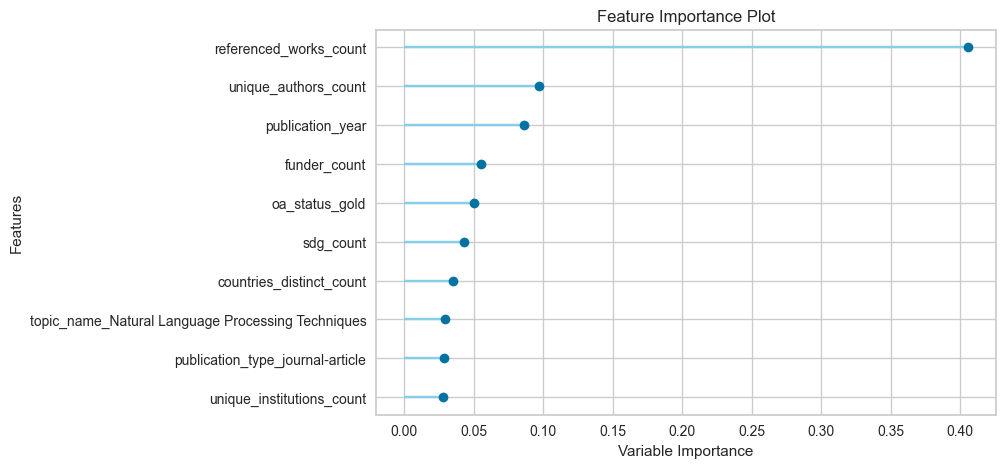

In [35]:
# Plot feature importance for the best model
plot_model(best_models[0], plot='feature')

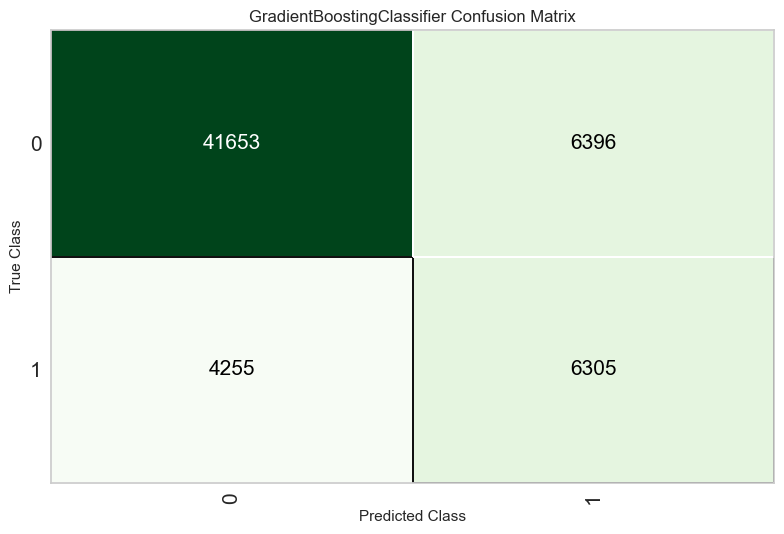

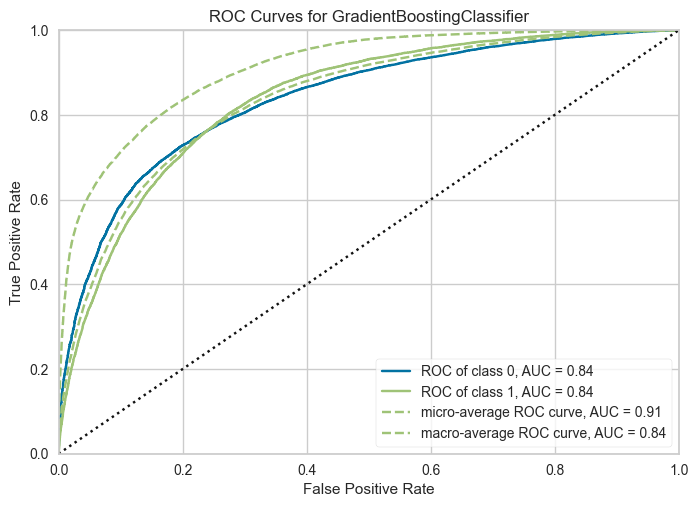

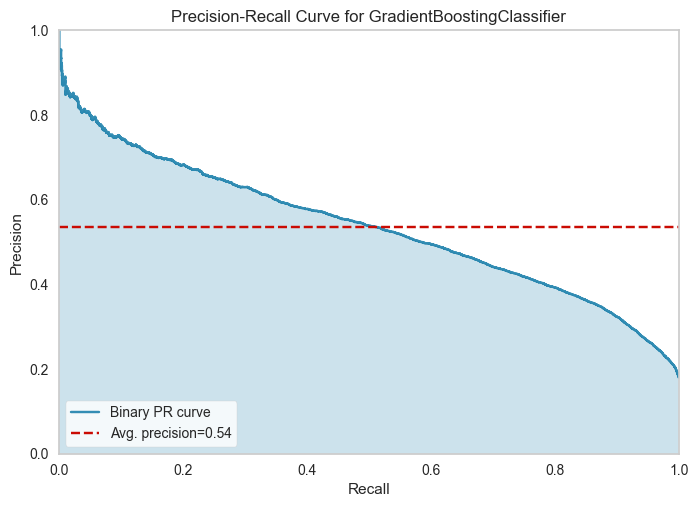

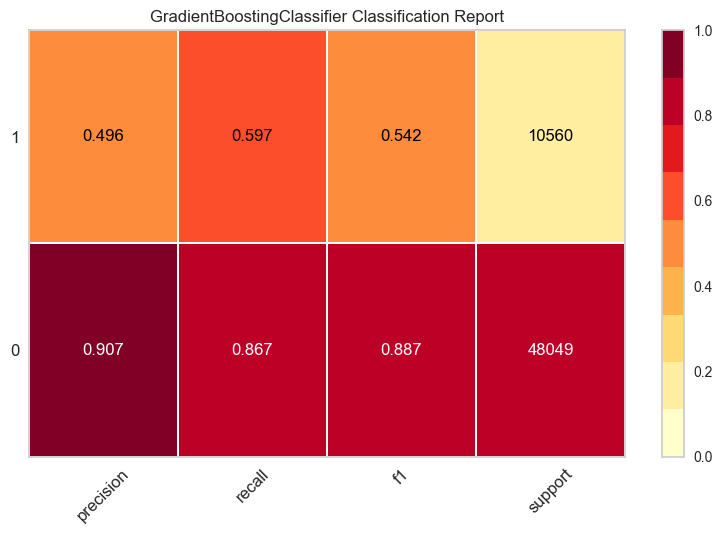

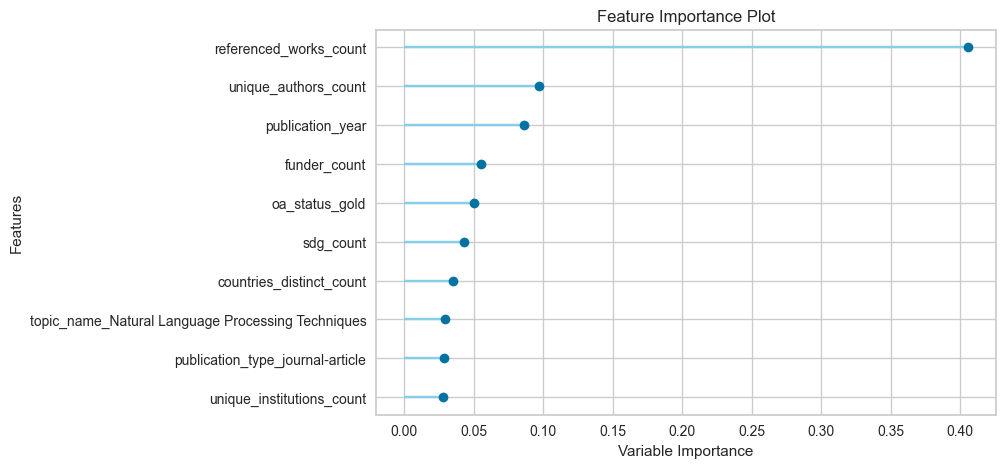

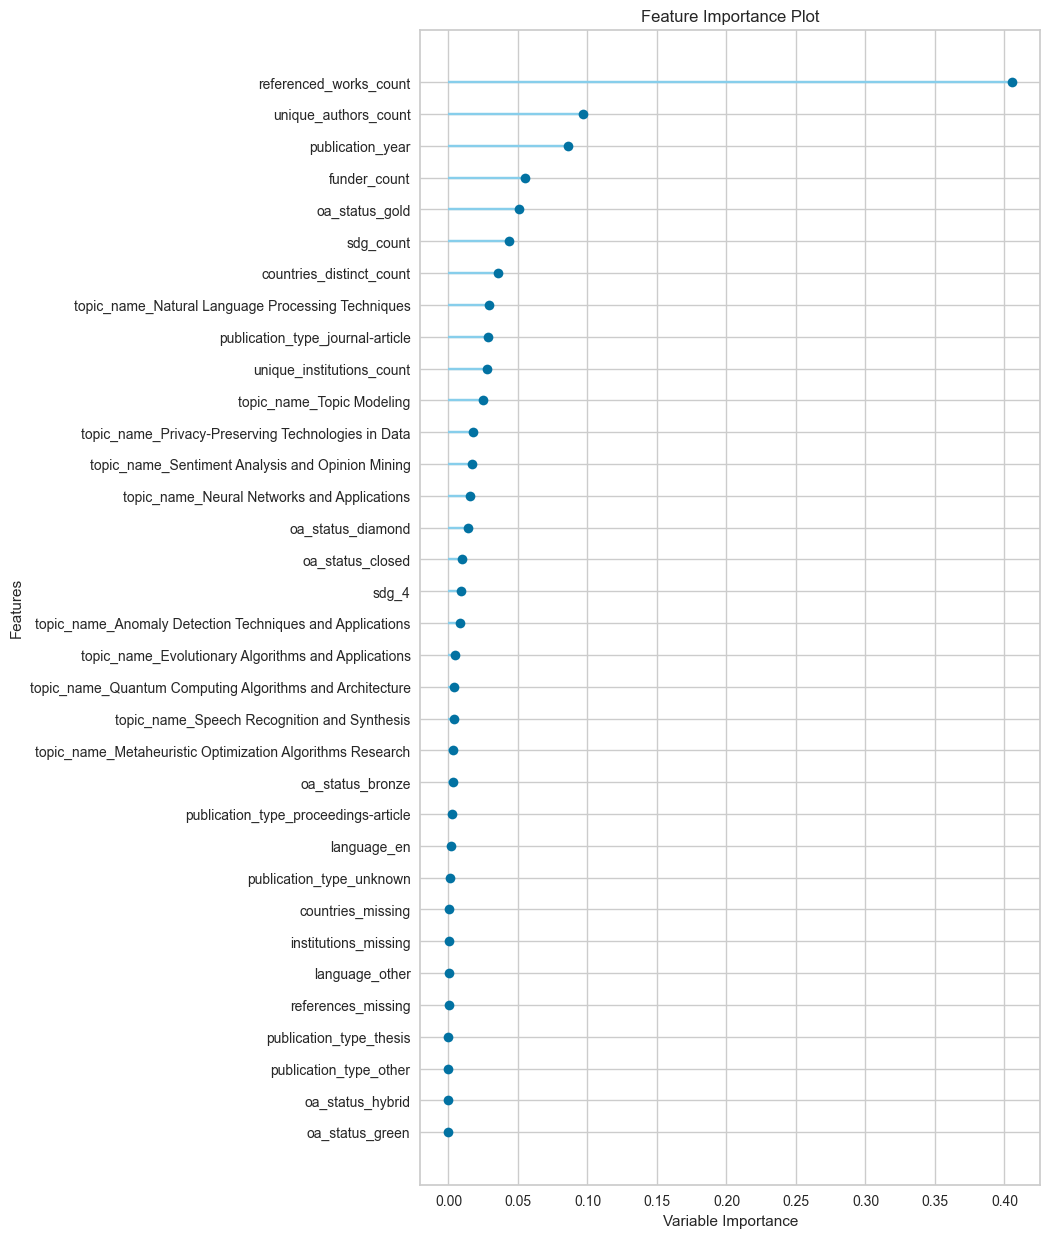

In [36]:
# Confusion matrix — shows true/false positives and negatives
plot_model(best_models[0], plot='confusion_matrix')

# AUC-ROC curve
plot_model(best_models[0], plot='auc')

# Precision-Recall curve — more informative than AUC for imbalanced data
plot_model(best_models[0], plot='pr')

# Classification report — precision, recall, F1 per class
plot_model(best_models[0], plot='class_report')

# Feature importance
plot_model(best_models[0], plot='feature')

# Feature importance
plot_model(best_models[0], plot='feature_all')

## Model Evaluation — GBC Trimmed + Missingness Flags (Pre-Tuning)

### Results Across All Runs

| Metric | First Model | Enriched | Trimmed | Trimmed + Flags |
|---|---|---|---|---|
| F1 | 0.54 | 0.53 | 0.54 | 0.54 |
| AUC | 0.84 | 0.84 | 0.84 | 0.84 |
| Recall | 0.61 | 0.53 | 0.59 | 0.60 |
| Precision | 0.49 | 0.53 | 0.50 | 0.50 |
| True Positives | 6,421 | 5,563 | 6,267 | 6,305 |
| False Negatives | 4,139 | 4,997 | 4,293 | 4,255 |

### Interpretation

Missingness flags produced a small but consistent improvement — catching 38 more
high-impact papers than the trimmed model without flags. AUC and PR AUC unchanged
at 0.84 and 0.54 across all runs — the model's discriminative power is stable.

Feature importance remains clean and interpretable: `referenced_works_count`
dominant (0.40), `unique_authors_count` (0.10) and `publication_year` (0.09)
as the next strongest signals. Missingness flags are present but small —
contributing without distorting the model.

### Decision

Best pre-tuning result across all runs. Proceed with overnight GBC tuning
using `optimize='F1'`, `n_iter=50`, bayesian search.

## SHAP analysis - XGB model

In [37]:
# Create and save XGBoost model
xgb = create_model('xgboost', session_id=42)
save_model(xgb, '../models/xgb_trimmed')
print("Saved: models/xgb_trimmed.pkl")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8477,0.8521,0.4112,0.6157,0.4931,0.4076,0.4192
1,0.8448,0.8508,0.4003,0.6046,0.4817,0.3948,0.4064
2,0.8494,0.8534,0.4062,0.6265,0.4929,0.4091,0.4224
3,0.8483,0.8501,0.4176,0.6166,0.4980,0.4125,0.4233
4,0.8453,0.8502,0.3934,0.6097,0.4782,0.3923,0.4053
5,0.8447,0.8474,0.3979,0.6053,0.4801,0.3934,0.4054
6,0.8469,0.8564,0.4136,0.6108,0.4932,0.4069,0.4177
7,0.8476,0.8536,0.3996,0.6197,0.4859,0.4013,0.4146
8,0.8483,0.8496,0.3968,0.6242,0.4852,0.4013,0.4155


Transformation Pipeline and Model Successfully Saved
Saved: models/xgb_trimmed.pkl


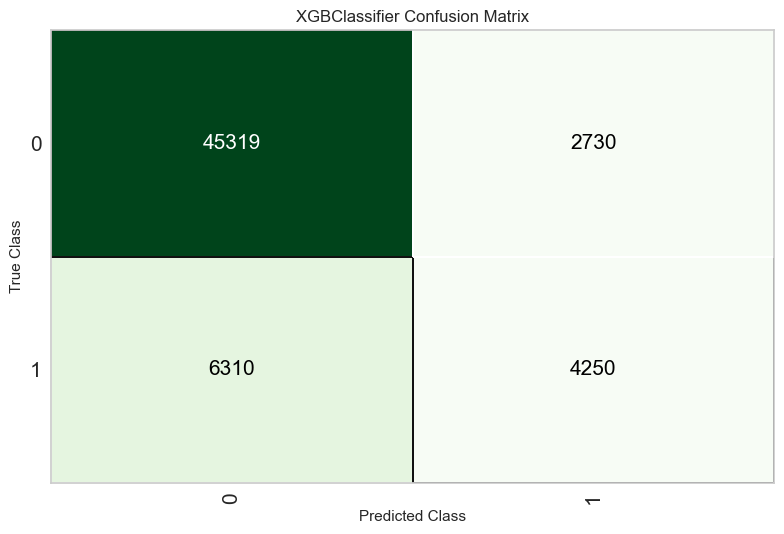

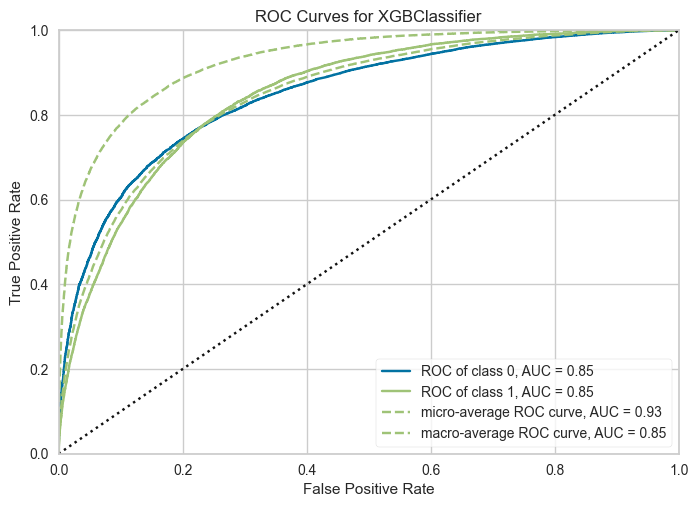

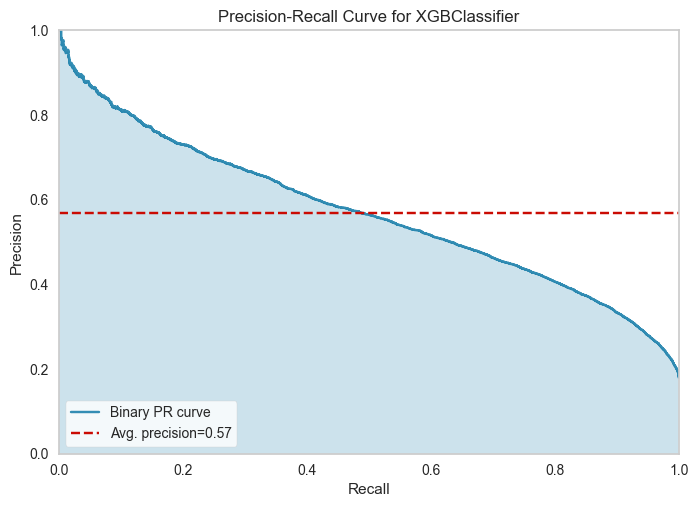

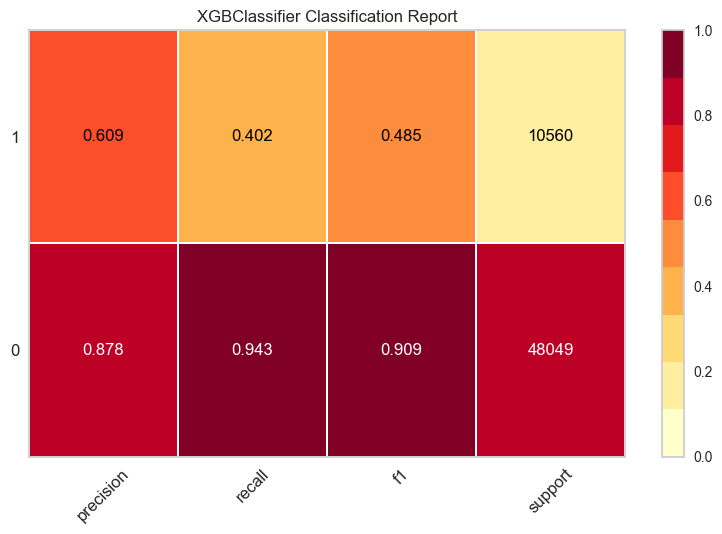

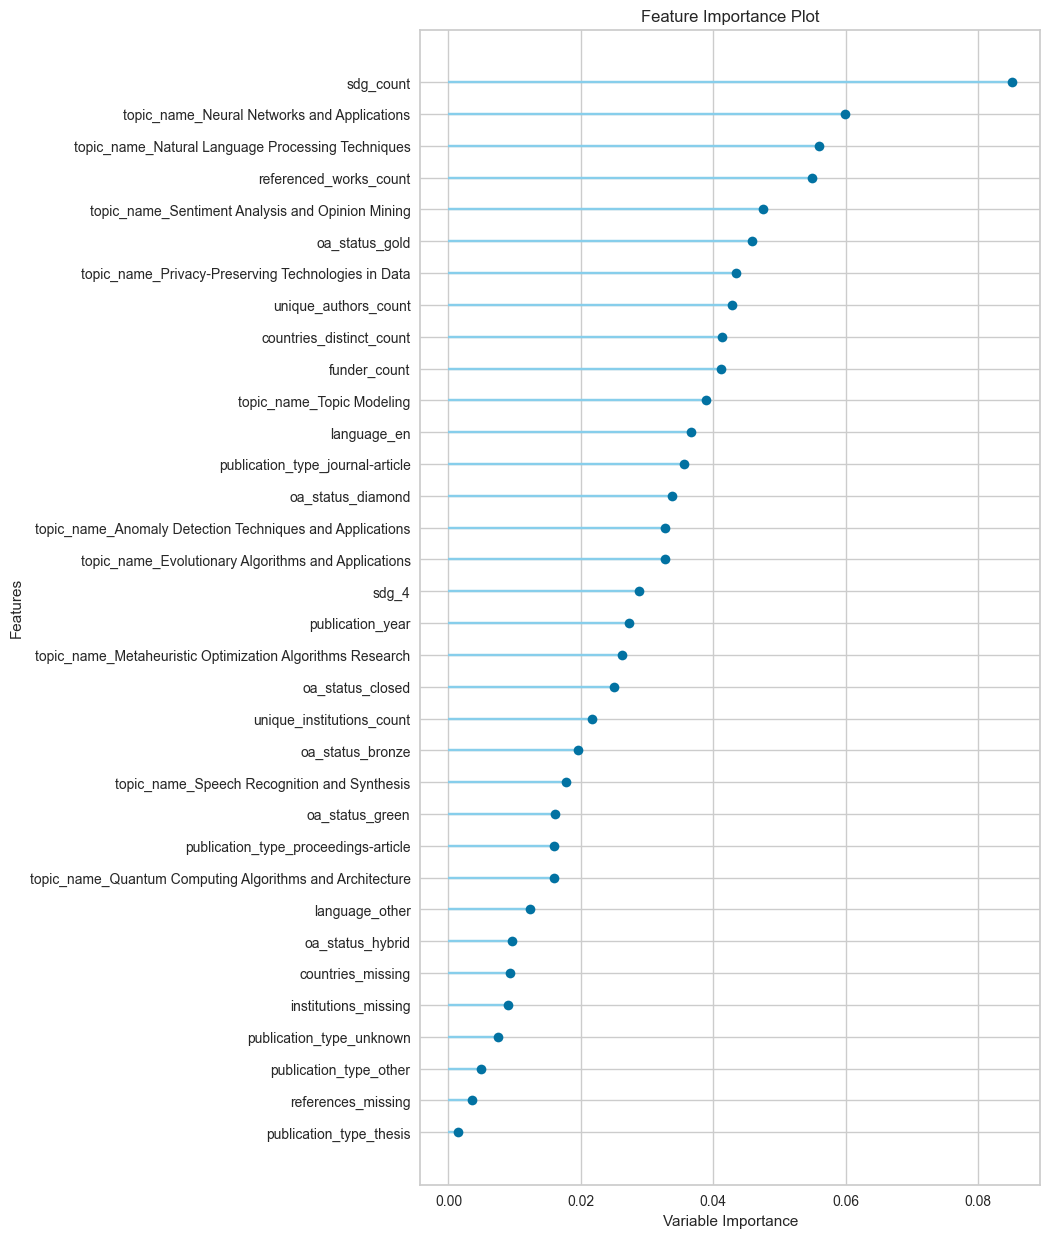

In [38]:
plot_model(xgb, plot='confusion_matrix')
plot_model(xgb, plot='auc')
plot_model(xgb, plot='pr')
plot_model(xgb, plot='class_report')
plot_model(xgb, plot='feature_all')

## Model Evaluation — XGBoost Trimmed + Missingness Flags

### Results Across All Runs

| Metric | XGBoost Enriched | XGBoost Trimmed | XGBoost Trimmed + Flags |
|---|---|---|---|
| F1 | 0.48 | 0.49 | 0.49 |
| AUC | 0.85 | 0.85 | 0.85 |
| Recall | 0.39 | 0.40 | 0.40 |
| Precision | 0.63 | 0.61 | 0.61 |
| True Positives | 4,077 | 4,263 | 4,250 |
| False Negatives | 6,483 | 6,297 | 6,310 |

### Interpretation

Missingness flags made no difference — metrics unchanged across trimmed runs.
XGBoost remains structurally precision-heavy regardless of feature changes,
missing 6,310 high-impact papers on the test set.

Feature importance still distorted — `sdg_count` dominant at 0.09 despite
ρ=0.04 with the target, `referenced_works_count` only 4th. This pattern
has been consistent across all three XGBoost runs.

### Decision

XGBoost ruled out across all runs. No feature engineering has shifted the
precision-heavy behaviour or the feature importance distortion. GBC taken
forward to overnight tuning.

## AdaBoost check

In [6]:


ada = create_model('ada')
save_model(ada, '../models/ada_trimmed')
print("Saved: models/ada_trimmed.pkl")



,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7833,0.8183,0.6546,0.4329,0.5212,0.3885,0.4024
1,0.7805,0.8186,0.6551,0.4286,0.5182,0.3840,0.3985
2,0.7875,0.8241,0.6572,0.4400,0.5271,0.3969,0.4102
3,0.7788,0.8150,0.6510,0.4256,0.5147,0.3795,0.3939
4,0.7772,0.8189,0.6580,0.4238,0.5156,0.3796,0.3950
5,0.7762,0.8146,0.6540,0.4220,0.5129,0.3763,0.3915
6,0.7857,0.8213,0.6607,0.4374,0.5264,0.3952,0.4093
7,0.7849,0.8206,0.6480,0.4350,0.5205,0.3887,0.4016
8,0.7764,0.8151,0.6534,0.4222,0.5130,0.3765,0.3916


Transformation Pipeline and Model Successfully Saved
Saved: models/ada_trimmed.pkl


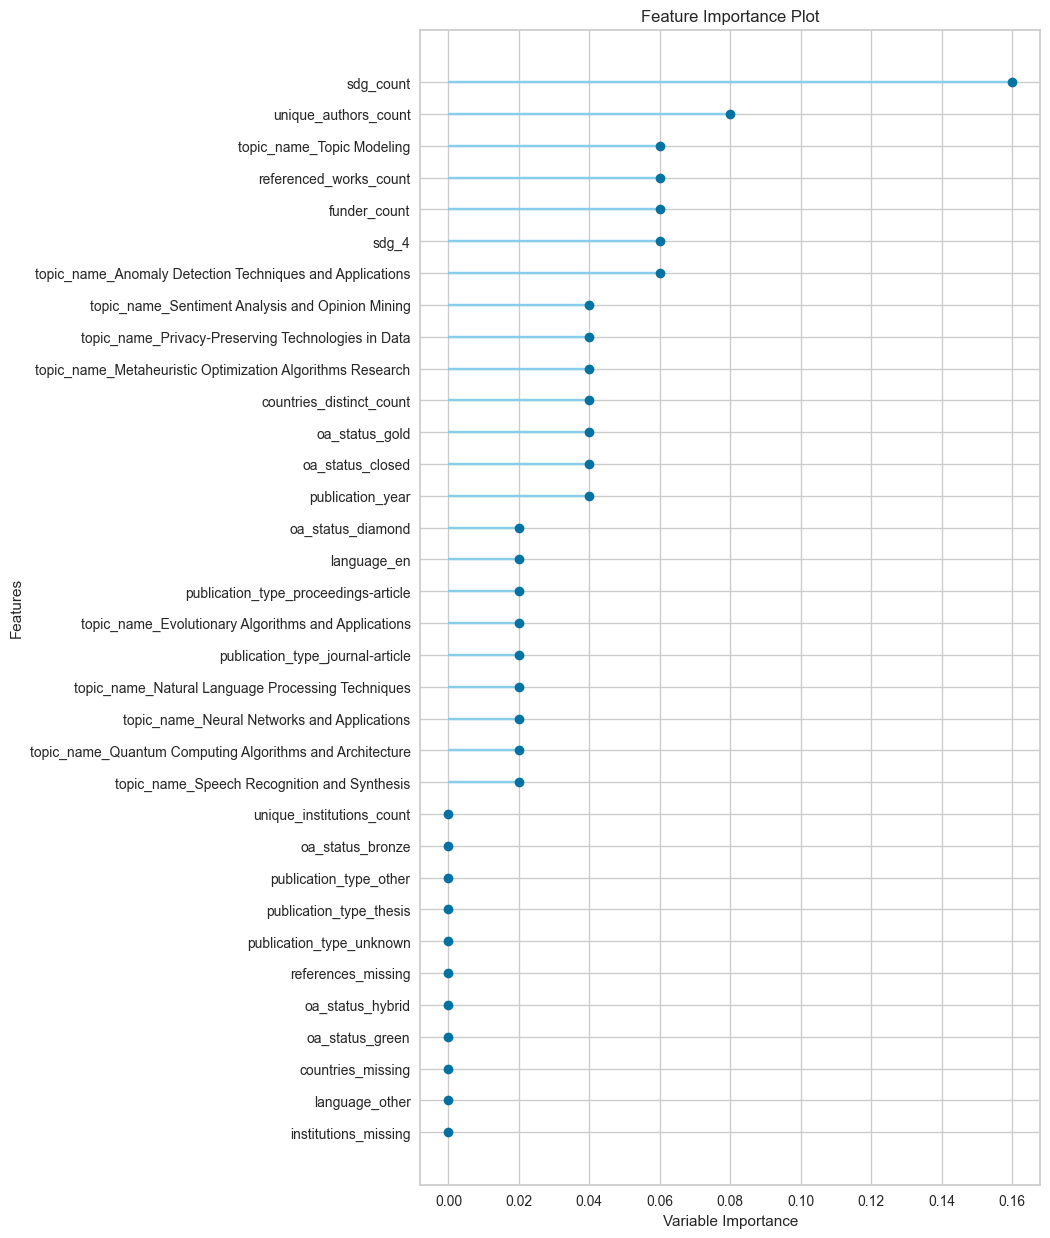

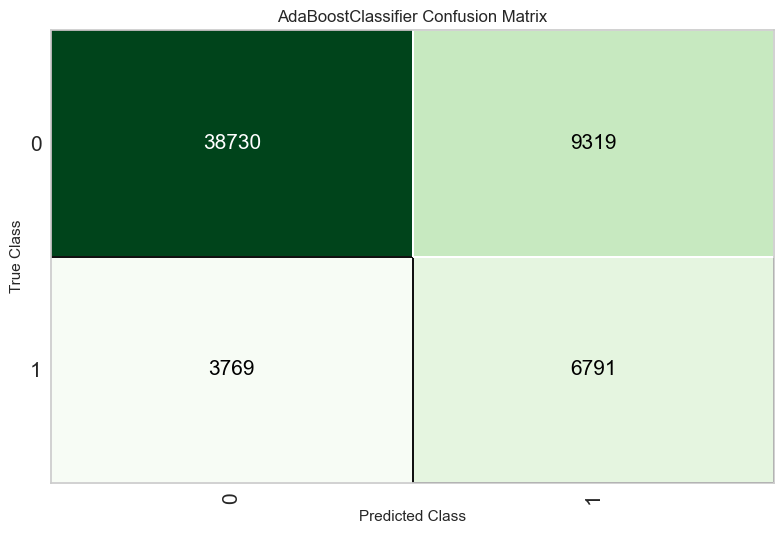

In [8]:
# Feature importance plots
plot_model(ada, plot='feature_all')
plot_model(ada, plot='confusion_matrix')

## Model Evaluation — AdaBoost (Trimmed + Flags)

| Metric | AdaBoost | GBC |
|---|---|---|
| Recall | 0.64 | 0.60 |
| Precision | 0.42 | 0.50 |
| F1 | 0.52 | 0.54 |
| True Positives | 6,791 | 6,305 |
| False Positives | 9,319 | 6,396 |

### Interpretation

AdaBoost has higher recall than GBC (0.64 vs 0.60) but generates 2,923 more
false positives — precision drops to 0.42. For the publisher use case this is
too noisy: flagging 9,319 papers to find 6,791 high-impact ones is not
operationally useful.

Feature importance is distorted — `sdg_count` dominant at 0.16 despite ρ=0.04,
`referenced_works_count` only 4th. Same pattern as XGBoost. AdaBoost's high
recall is coming from casting a wide net rather than genuinely identifying
high-impact papers.

### Decision

AdaBoost ruled out. GBC confirmed as the model to tune — cleaner feature
importance, better precision/recall balance, more defensible for the business case.

## CatBoost check

In [9]:

catboost = create_model('catboost')
save_model(catboost, '../models/catboost_trimmed')
print("Saved: models/catboost_trimmed.pkl")



,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8491,0.8556,0.3984,0.6280,0.4875,0.4042,0.4186
1,0.8486,0.8525,0.3946,0.6267,0.4843,0.4009,0.4156
2,0.8505,0.8565,0.3875,0.6410,0.4830,0.4018,0.4192
3,0.8477,0.8522,0.3883,0.6243,0.4788,0.3952,0.4105
4,0.8466,0.8519,0.3742,0.6242,0.4679,0.3848,0.4020
5,0.8447,0.8499,0.3813,0.6105,0.4694,0.3840,0.3987
6,0.8502,0.8586,0.3956,0.6356,0.4877,0.4055,0.4211
7,0.8484,0.8554,0.3814,0.6313,0.4755,0.3931,0.4102
8,0.8479,0.8518,0.3788,0.6294,0.4730,0.3904,0.4076


Transformation Pipeline and Model Successfully Saved
Saved: models/catboost_trimmed.pkl


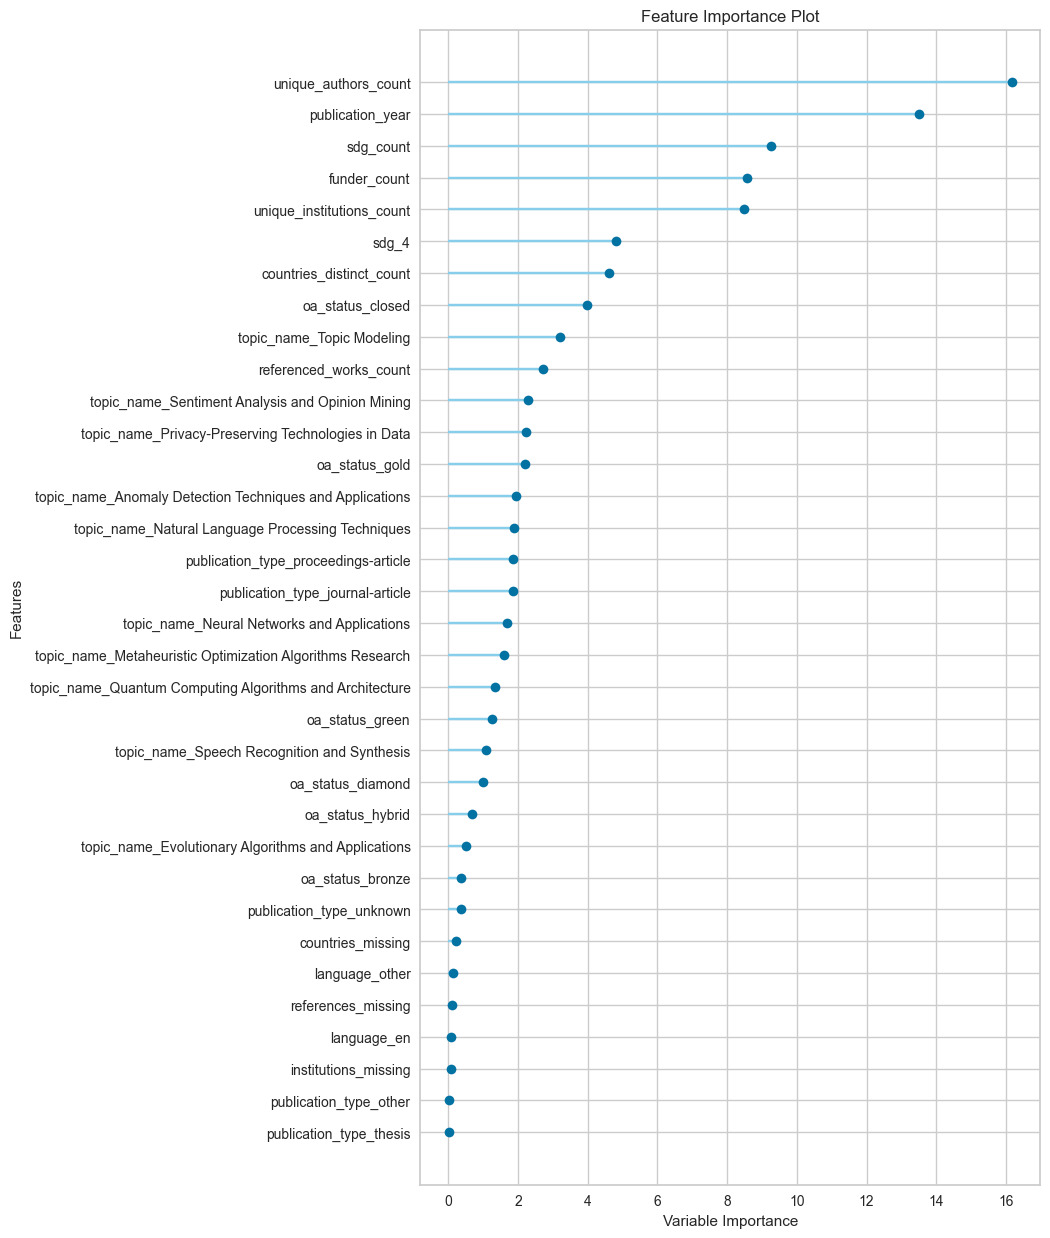

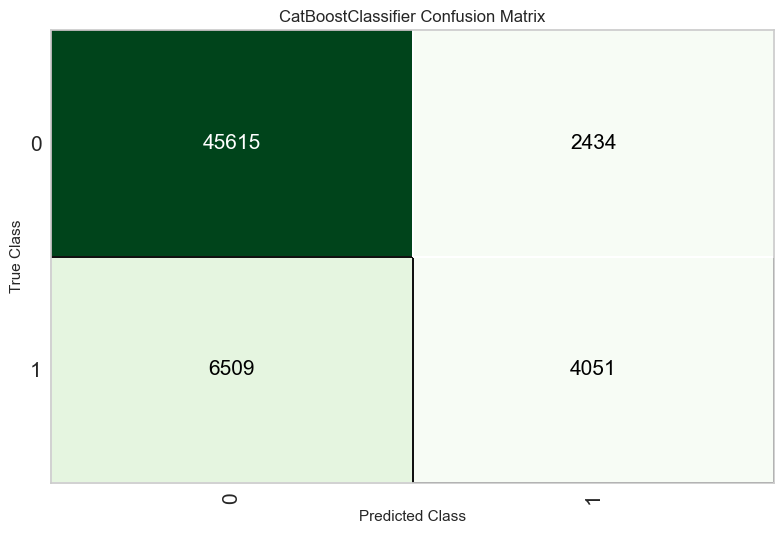

In [11]:

# Feature importance plots
plot_model(catboost, plot='feature_all')
plot_model(catboost, plot='confusion_matrix')

## Model Evaluation — CatBoost (Trimmed + Flags)

| Metric | CatBoost | GBC |
|---|---|---|
| Recall | 0.38 | 0.60 |
| Precision | 0.62 | 0.50 |
| F1 | 0.47 | 0.54 |
| True Positives | 4,051 | 6,305 |
| False Negatives | 6,509 | 4,255 |

### Interpretation

CatBoost is the most conservative model — highest precision (0.62) but lowest
recall (0.38), missing 6,509 high-impact papers. Wrong tradeoff for the
publisher use case.

Feature importance is distorted — `unique_authors_count` dominant at 16,
`publication_year` second at 14, `referenced_works_count` only 10th despite
being the strongest predictor by correlation (ρ=0.39). CatBoost's native
categorical encoding changes feature weighting significantly compared to GBC.

### Decision

CatBoost ruled out. Could be revisited for a high-confidence shortlist use
case (funder wanting maximum precision) but not appropriate as the primary model.

## Statistical Tests — Binary Features vs Target (in 09 notebook)

Chi-squared test and Cramér's V for all binary features against
`citation_top_10_percent`. With 234k rows all associations are statistically
significant (p=0.00) except where noted — Cramér's V is the meaningful measure.

### Consistency with Model Feature Importance

Cross-referencing Cramér's V with feature importance across all four models
confirms GBC as the most statistically coherent model:

| Model | Feature importance consistent with statistics? |
|---|---|
| GBC | ✅ Yes — rankings match Cramér's V and correlation |
| XGBoost | ❌ No — `sdg_count` inflated, `referenced_works_count` suppressed |
| AdaBoost | ❌ No — `sdg_count` dominant despite Cramér's V of only 0.03 |
| CatBoost | ❌ No — `unique_authors_count` and `publication_year` inflated |

GBC is the only model whose feature importance rankings are consistent with
both the statistical tests and the EDA correlations. This reinforces GBC as
the correct model choice beyond just F1 performance.


`referenced_works_count` confirmed as the dominant predictor by three independent
methods — EDA, statistical tests, and GBC feature importance. GBC is the only
model whose feature rankings are consistent with the statistical evidence.
XGBoost and AdaBoost over-weight `sdg_count` despite its small effect size,
further confirming GBC as the correct model choice.

## GBC model tunning

In [ ]:
# =============================================================================
# NOTEBOOK 10 | CELL — TUNE GBC OVERNIGHT (optimize='F1')
# =============================================================================

# Bayesian hyperparameter search optimising for F1
# - F1 balances precision and recall — appropriate for publisher use case
# - search_library='scikit-optimize' + bayesian: learns from previous iterations,
#   more efficient than random search on large datasets
# - n_iter=50: 50 bayesian iterations — run overnight
# - early_stopping=True: halts if no improvement after several iterations
# - choose_better=True: returns tuned model only if it improves on baseline

from pycaret.classification import load_model

gbc = load_model('../models/gbc_trimmed')

tuned_gbc = tune_model(
    gbc,
    optimize         = 'F1',
    n_iter           = 50,
    search_library   = 'scikit-optimize',
    search_algorithm = 'bayesian',
    early_stopping   = True,
    choose_better    = True,
    verbose          = True
)

# Save tuned model immediately after completion
save_model(tuned_gbc, '../models/gbc_tuned')
print("Saved: models/gbc_tuned.pkl")